setup--libraries

In [166]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, 
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)
import lightgbm as lgb

project_id = "olist-analytics-493621"
client = bigquery.Client(project=project_id)
print("Connected!")
print(f"LightGBM version: {lgb.__version__}")

python(34070) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Connected!
LightGBM version: 4.6.0


Pull data from BigQuery

In [167]:
df = client.query("""
    SELECT
        c.customer_unique_id,
        c.customer_state,
        c.total_orders,
        c.total_spent,
        c.avg_order_value,
        c.customer_lifespan_days,
        c.days_since_last_order,
        c.delivered_orders,
        #c.cancelled_orders,
        r.kmeans_cluster
    FROM `olist_analytics.mart_customer_orders` c
    LEFT JOIN `olist_analytics.ml_kmeans_segments` r
        ON c.customer_unique_id = r.customer_unique_id
    WHERE c.total_orders > 0
""").to_dataframe()

print(f"Total customers: {len(df):,}")
df.head()

/Users/maytilok/dbt-env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Total customers: 96,459


,customer_unique_id,customer_state,total_orders,total_spent,avg_order_value,customer_lifespan_days,days_since_last_order,delivered_orders,kmeans_cluster
0,94742cd1fbac9146be7e2a139b63e13c,AC,1,62.92,62.920,0,453,1,1
1,5dbba6c01268a8ad43f79157bf4454a0,AC,2,496.87,248.435,91,242,2,2
2,4f67110f6d6d1241111167b141bfa780,AC,1,94.37,94.370,0,373,0,1
3,f7d7fc0a59ef4363fdce6e3aa069d498,AC,2,177.85,88.925,295,190,2,2
4,36b1c0516f123351ffa87430416dcae5,AC,1,321.92,321.920,0,421,1,1


# Define churn label

## Churn Threshold — Design Decision

### What can be threshold
Attempted to calculate dynamic per-customer churn thresholds
based on 
1. individual purchase cycles: use individual purchase cycles
2. category-based: Different product categories have different natural repurchase cycles

Exploratory on purchsing distribution


In [168]:
# Percentage of customers by order count
order_counts = df['total_orders'].value_counts().sort_index()

one_time = (df['total_orders'] == 1).sum()
total    = len(df)
pct      = one_time / total * 100
avg_order     = df['total_orders'].sum()/total 

print(f"Total customers:                {total:,}")
print(f"Single order customers:         {one_time:,} ({pct:.1f}%)")
print(f"Repeat customers:               {total - one_time:,} ({100-pct:.1f}%)")
print(f"Average order per customers:    {avg_order:.5f}")

Total customers:                96,459
Single order customers:         93,562 (97.0%)
Repeat customers:               2,897 (3.0%)
Average order per customers:    1.03353


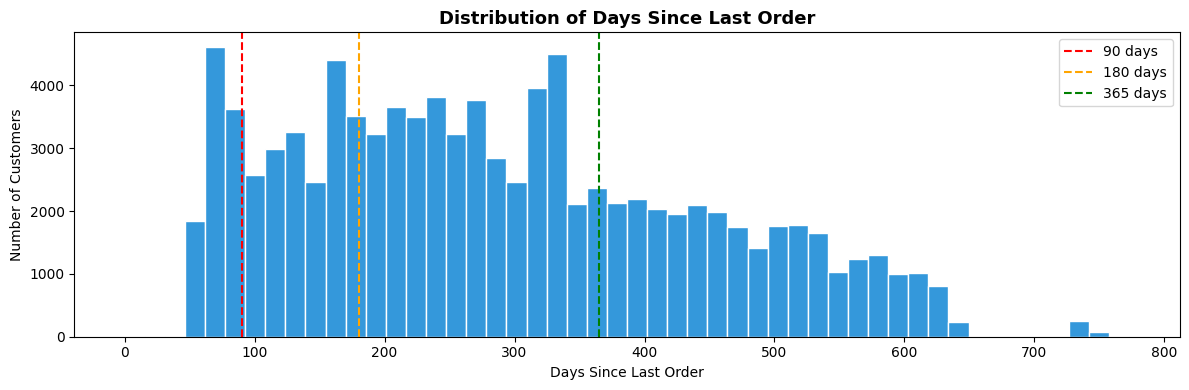

Min days since last order:    0
Max days since last order:    773
Median days since last order: 269
Mean days since last order:   288


In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.hist(df['days_since_last_order'], bins=50, 
         color='#3498db', edgecolor='white')
plt.axvline(x=90,  color='red',    linestyle='--', label='90 days')
plt.axvline(x=180, color='orange', linestyle='--', label='180 days')
plt.axvline(x=365, color='green',  linestyle='--', label='365 days')
plt.title('Distribution of Days Since Last Order', 
          fontsize=13, fontweight='bold')
plt.xlabel('Days Since Last Order')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Min days since last order:    {df['days_since_last_order'].min():.0f}")
print(f"Max days since last order:    {df['days_since_last_order'].max():.0f}")
print(f"Median days since last order: {df['days_since_last_order'].median():.0f}")
print(f"Mean days since last order:   {df['days_since_last_order'].mean():.0f}")

### Churn Threshold — Final Decision

### What the Data Shows
Repeat customers: < 3% of total base
Avg orders per customer: 1.03
- 97% of customers have exactly one order
- No purchase cycle exists to calculate

**Problem identified:** Right-censoring bias
- Dataset ends Oct 2018
- Most customers' last orders were 200-300 days ago
- High "churn" rates reflect dataset end, not real behavior

**Solution:** Active customer window
1. Use 90 days for general churn for e-commerce
2. Restricted analysis to customers active in last 180 days
    - Applied 90-day churn threshold within this window
    - Results in realistic ~45% churn rate vs artificially inflated 90%

**Threshold validation:**
- 90 days = industry standard for e-commerce
- Balances class distribution for model training

# Solution 1 - Use 90 days for general churn for e-commerce

In [170]:
CHURN_THRESHOLD = 90

df['churned'] = (df['days_since_last_order'] > CHURN_THRESHOLD).astype(int)

churn_rate = df['churned'].mean() * 100
print(f"Churn rate:         {churn_rate:.1f}%")
print(f"Churned customers:  {df['churned'].sum():,}")
print(f"Active customers:   {(df['churned'] == 0).sum():,}")

Churn rate:         90.1%
Churned customers:  86,869
Active customers:   9,590


# Feature engineering

In [171]:
# Fill missing data

df['customer_lifespan_days'] = df['customer_lifespan_days'].fillna(0)
df['delivered_orders']       = df['delivered_orders'].fillna(0)

# Engineered features

df['delivery_success_rate'] = (
    df['delivered_orders'] / df['total_orders']
).fillna(0)

df['is_repeat_buyer'] = (df['total_orders'] > 1).astype(int)

# Encode state
df['state_code'] = df['customer_state'].astype('category').cat.codes

print("Features engineered!")
print(f"Dataset shape: {df.shape}")

Features engineered!
Dataset shape: (96459, 13)


In [172]:
df.head()

,customer_unique_id,customer_state,total_orders,total_spent,avg_order_value,customer_lifespan_days,days_since_last_order,delivered_orders,kmeans_cluster,churned,delivery_success_rate,is_repeat_buyer,state_code
0,94742cd1fbac9146be7e2a139b63e13c,AC,1,62.92,62.920,0,453,1,1,1,1.0,0,0
1,5dbba6c01268a8ad43f79157bf4454a0,AC,2,496.87,248.435,91,242,2,2,1,1.0,1,0
2,4f67110f6d6d1241111167b141bfa780,AC,1,94.37,94.370,0,373,0,1,1,0.0,0,0
3,f7d7fc0a59ef4363fdce6e3aa069d498,AC,2,177.85,88.925,295,190,2,2,1,1.0,1,0
4,36b1c0516f123351ffa87430416dcae5,AC,1,321.92,321.920,0,421,1,1,1,1.0,0,0


### Exploratory Feature Analysis

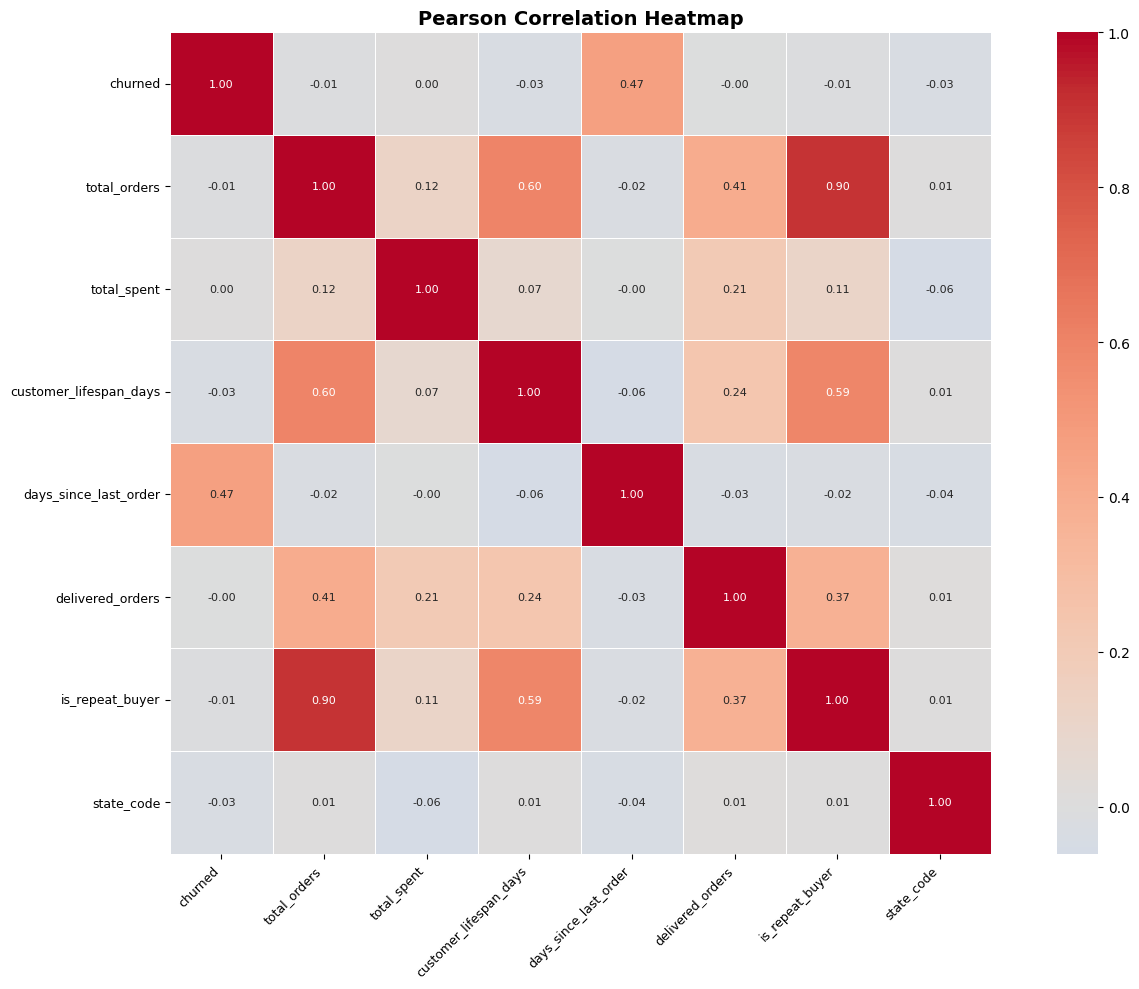

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
#numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = df[[ 'churned',
    'total_orders',
    'total_spent',
    'customer_lifespan_days',
    'days_since_last_order',
    'delivered_orders',
    'is_repeat_buyer',
    'state_code'
]]

# Compute correlation matrix
corr_matrix = numeric_cols.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../dashboard/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Train and test set

In [ ]:
FEATURES = [
    'total_orders',
    'total_spent',
    'customer_lifespan_days',
    'days_since_last_order',
    'delivered_orders',
    'is_repeat_buyer',
    'state_code'
]

X = df[FEATURES]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:     {len(X_train):,} rows")
print(f"Test set:         {len(X_test):,} rows")
print(f"Churn rate train: {y_train.mean()*100:.1f}%")
print(f"Churn rate test:  {y_test.mean()*100:.1f}%")
print(f"\nFeatures: {FEATURES}")

Training set:     77,167 rows
Test set:         19,292 rows
Churn rate train: 90.1%
Churn rate test:  90.1%

Features: ['total_orders', 'total_spent', 'customer_lifespan_days', 'days_since_last_order', 'delivered_orders', 'is_repeat_buyer', 'state_code']


# Train LightGBM model

In [175]:
#imbalance data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(20, verbose=False)]
)

print("Model trained!")

scale_pos_weight: 0.11
Model trained!


In [176]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Check for overfitting
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
test_auc  = roc_auc_score(y_test, y_pred_proba)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Gap:       {train_auc - test_auc:.4f}")
print()
print("Gap interpretation:")
if train_auc - test_auc < 0.02:
    print("No overfitting — model is healthy")
elif train_auc - test_auc < 0.05:
    print("Mild overfitting — acceptable")
else:
    print("Overfitting — consider removing features")

print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Train AUC: 1.0000
Test AUC:  1.0000
Gap:       0.0000

Gap interpretation:
No overfitting — model is healthy

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1918
           1       1.00      1.00      1.00     17374

    accuracy                           1.00     19292
   macro avg       0.99      1.00      0.99     19292
weighted avg       1.00      1.00      1.00     19292



### The model is underfitting. AUD of 1
**Reason** 
churned = days_since_last_order > 90

The model predict churn using the EXACT variable that defines churn

This is direct target leakage.


In [179]:
FEATURES = [
    'total_orders',
    'total_spent',
    'customer_lifespan_days',
    #'days_since_last_order',
    'delivered_orders',
    'is_repeat_buyer',
    'state_code'
]

X = df[FEATURES]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:     {len(X_train):,} rows")
print(f"Test set:         {len(X_test):,} rows")
print(f"Churn rate train: {y_train.mean()*100:.1f}%")
print(f"Churn rate test:  {y_test.mean()*100:.1f}%")
print(f"\nFeatures: {FEATURES}")

Training set:     77,167 rows
Test set:         19,292 rows
Churn rate train: 90.1%
Churn rate test:  90.1%

Features: ['total_orders', 'total_spent', 'customer_lifespan_days', 'delivered_orders', 'is_repeat_buyer', 'state_code']


In [180]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(20, verbose=False)]
)

print("Model trained!")

scale_pos_weight: 0.11
Model trained!


In [181]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Check for overfitting
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
test_auc  = roc_auc_score(y_test, y_pred_proba)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Gap:       {train_auc - test_auc:.4f}")
print()
print("Gap interpretation:")
if train_auc - test_auc < 0.02:
    print("No overfitting — model is healthy")
elif train_auc - test_auc < 0.05:
    print("Mild overfitting — acceptable")
else:
    print("Overfitting — consider removing features")

print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Train AUC: 0.5564
Test AUC:  0.5472
Gap:       0.0091

Gap interpretation:
No overfitting — model is healthy

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1918
           1       0.90      1.00      0.95     17374

    accuracy                           0.90     19292
   macro avg       0.45      0.50      0.47     19292
weighted avg       0.81      0.90      0.85     19292



/Users/maytilok/dbt-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maytilok/dbt-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maytilok/dbt-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

### The model is underfitting. AUC of 0.54 is a little bit better than random guessing (0.5)
**Reason** 
Precision for class 0 = 0.00
→ Model predicts NOBODY as "not churned"
→ It just labels everyone as churned
→ This is a class imbalance problem

Active window customers:  ~5,594
  Churned (1):    3,676  (66%)
  Retained (0):   1,918  (34%)

### Solution 1: Not enough features to distinguish churned vs retained

In [223]:
df_add = client.query("""
    WITH customer_id_map AS (
        SELECT
            customer_id,
            customer_unique_id
        FROM `olist_analytics.stg_customers`
    ),
    
    orders_with_uid AS (
        SELECT
            o.*,
            m.customer_unique_id
        FROM `olist_analytics.stg_orders` o
        LEFT JOIN customer_id_map m
            ON o.customer_id = m.customer_id
    ),

    customer_features AS (
        SELECT
            c.customer_unique_id,
            c.customer_state,
            c.total_orders,
            c.total_spent,
            c.avg_order_value,
            c.customer_lifespan_days,
            c.days_since_last_order,
            c.delivered_orders,
            #c.cancelled_orders,

            -- Payment behavior
            AVG(CAST(p.payment_installments AS FLOAT64))
                AS avg_installments,
            COUNT(DISTINCT p.payment_type)
                AS num_payment_types,

            -- Product behavior
            COUNT(DISTINCT prod.product_category)
                AS num_categories_bought,

            -- Delivery experience
            AVG(CAST(o.delivery_days AS FLOAT64))
                AS avg_delivery_days,
            MAX(CAST(o.delivery_days AS FLOAT64))
                AS max_delivery_days,

            -- Order timing
            EXTRACT(MONTH FROM MIN(DATE(o.purchased_at)))
                AS first_order_month,
            EXTRACT(DAYOFWEEK FROM MAX(DATE(o.purchased_at)))
                AS last_order_dayofweek,

            -- Freight behavior
            AVG(i.freight_value)
                AS avg_freight_value,
            AVG(i.freight_value / NULLIF(i.price, 0))
                AS avg_freight_ratio

        FROM `olist_analytics.mart_customer_orders` c
        LEFT JOIN orders_with_uid o
            ON c.customer_unique_id = o.customer_unique_id
        LEFT JOIN `olist_analytics.stg_order_payments` p
            ON o.order_id = p.order_id
        LEFT JOIN `olist_analytics.stg_order_items` i
            ON o.order_id = i.order_id
        LEFT JOIN `olist_analytics.stg_products` prod
            ON i.product_id = prod.product_id
        GROUP BY
            c.customer_unique_id,
            c.customer_state,
            c.total_orders,
            c.total_spent,
            c.avg_order_value,
            c.customer_lifespan_days,
            c.days_since_last_order,
            c.delivered_orders,
            c.cancelled_orders
    )

    SELECT * FROM customer_features
""").to_dataframe()

print(f"Total customers: {len(df_add):,}")
print(f"Columns: {df_add.columns.tolist()}")

/Users/maytilok/dbt-env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Total customers: 96,216
Columns: ['customer_unique_id', 'customer_state', 'total_orders', 'total_spent', 'avg_order_value', 'customer_lifespan_days', 'days_since_last_order', 'delivered_orders', 'avg_installments', 'num_payment_types', 'num_categories_bought', 'avg_delivery_days', 'max_delivery_days', 'first_order_month', 'last_order_dayofweek', 'avg_freight_value', 'avg_freight_ratio']


In [224]:
df_add

,customer_unique_id,customer_state,total_orders,total_spent,avg_order_value,customer_lifespan_days,days_since_last_order,delivered_orders,avg_installments,num_payment_types,num_categories_bought,avg_delivery_days,max_delivery_days,first_order_month,last_order_dayofweek,avg_freight_value,avg_freight_ratio
0,5dbba6c01268a8ad43f79157bf4454a0,AC,2,496.87,248.435,91,242,2,5.5,1,2,30.5,41.0,11,7,68.845,0.390456
1,f7d7fc0a59ef4363fdce6e3aa069d498,AC,2,177.85,88.925,295,190,2,5.0,1,1,45.0,72.0,6,3,26.480,0.438200
2,a73a341aa868b255594a9857c8e59772,AC,1,216.26,216.260,0,492,1,10.0,1,1,31.0,31.0,6,2,26.360,0.138810
3,62a459e5629b03dd73134964df732077,AC,1,1251.70,1251.700,0,409,1,8.0,1,1,67.0,67.0,9,1,51.700,0.043083
4,0b177893dc66d6d0f67ff1bf19423693,AC,1,58.92,58.920,0,230,1,5.0,1,1,43.0,43.0,3,5,31.020,1.111828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96211,8364e3d88524b949c7e2b5192c7bf368,TO,1,181.86,90.930,0,554,2,3.0,1,1,29.0,29.0,4,3,20.940,0.299186
96212,721406d1edfabad2de3f86155356d8e0,TO,1,74.61,74.610,0,237,1,1.0,1,1,29.0,29.0,2,5,25.630,0.523275
96213,61c3fd07327ec16b2905df628426d8ef,TO,1,468.80,468.800,0,547,1,8.0,1,1,29.0,29.0,4,3,123.800,0.358841
96214,02c3fe273d4f8888613526c3a3d808ba,TO,1,56.79,56.790,0,287,1,5.0,1,1,29.0,29.0,1,4,26.890,0.899331


In [225]:
CHURN_THRESHOLD = 90

df_add['churned'] = (df_add['days_since_last_order'] > CHURN_THRESHOLD).astype(int)

churn_rate = df_add['churned'].mean() * 100
print(f"Churn rate:         {churn_rate:.1f}%")
print(f"Churned customers:  {df['churned'].sum():,}")
print(f"Active customers:   {(df['churned'] == 0).sum():,}")

Churn rate:         90.1%
Churned customers:  86,869
Active customers:   9,590


In [226]:
# Fill missing data

df_add['customer_lifespan_days'] = df_add['customer_lifespan_days'].fillna(0)
df_add['delivered_orders']       = df_add['delivered_orders'].fillna(0)

# Engineered features

df_add['delivery_success_rate'] = (
    df_add['delivered_orders'] / df_add['total_orders']
).fillna(0)

df_add['is_repeat_buyer'] = (df_add['total_orders'] > 1).astype(int)

# Encode state
df_add['state_code'] = df_add['customer_state'].astype('category').cat.codes

print("Features engineered!")
print(f"Dataset shape: {df.shape}")

Features engineered!
Dataset shape: (96459, 13)


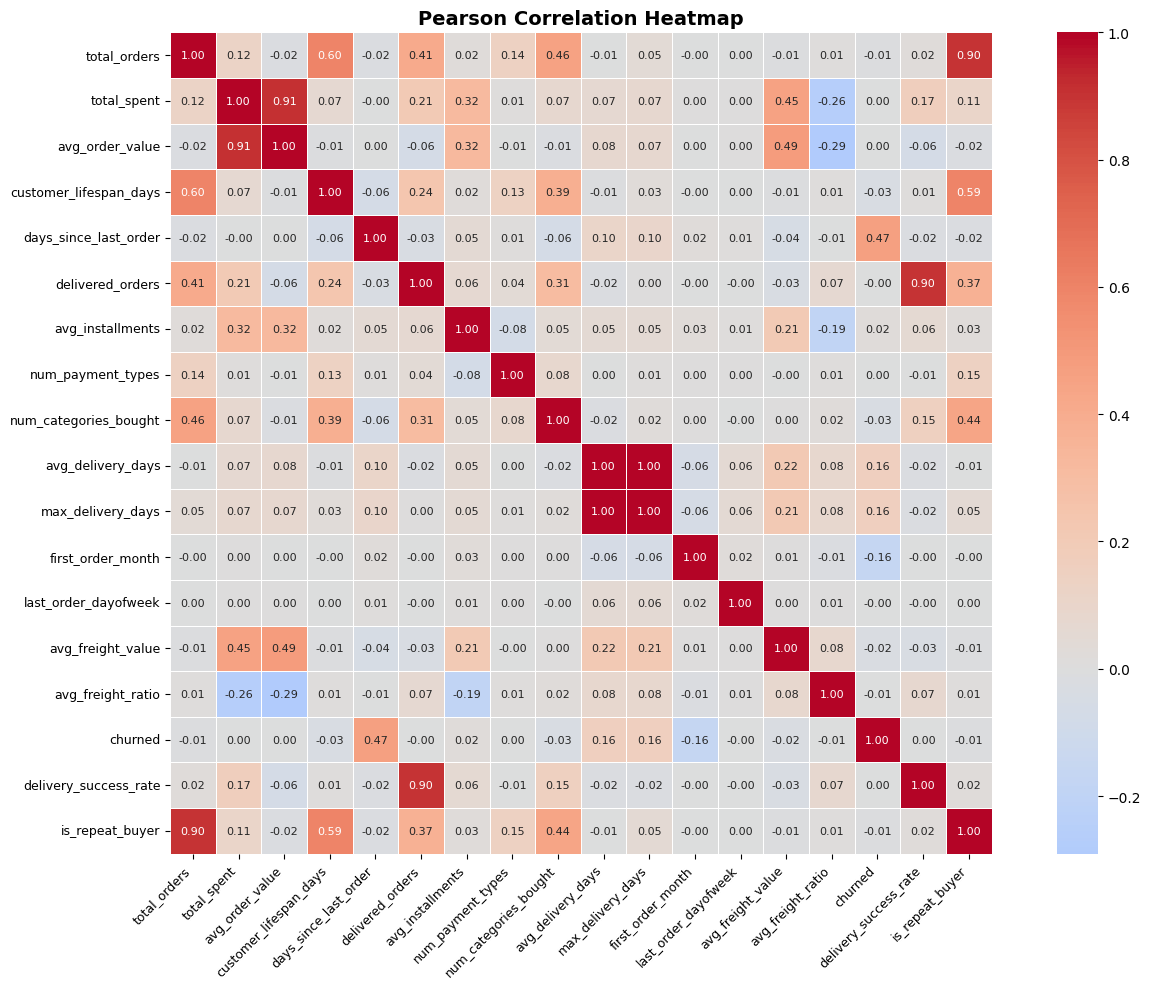

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
numeric_cols = df_add.select_dtypes(include=['int64', 'float64']).columns.tolist()
#numeric_cols = df[[ 'churned',
#    'total_orders',
#    'customer_lifespan_days',
#    'days_since_last_order',
#    'delivered_orders',
#    'is_repeat_buyer',
#    'state_code'
#]]

# Compute correlation matrix
corr_matrix = df_add[numeric_cols].corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../dashboard/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [217]:
FEATURES = [
    'first_order_month',

    #'total_orders',
    #'total_spent',
    'avg_installments',
    'num_categories_bought',
    'avg_delivery_days',
    'max_delivery_days',
    'customer_lifespan_days',
    'avg_freight_value',
    #'delivered_orders',
    #'is_repeat_buyer',
    'state_code',
]

X = df_add[FEATURES]
y = df_add['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:     {len(X_train):,} rows")
print(f"Test set:         {len(X_test):,} rows")
print(f"Churn rate train: {y_train.mean()*100:.1f}%")
print(f"Churn rate test:  {y_test.mean()*100:.1f}%")
print(f"\nFeatures: {FEATURES}")

Training set:     76,972 rows
Test set:         19,244 rows
Churn rate train: 90.1%
Churn rate test:  90.0%

Features: ['first_order_month', 'avg_installments', 'num_categories_bought', 'avg_delivery_days', 'max_delivery_days', 'customer_lifespan_days', 'avg_freight_value', 'state_code']


In [218]:
#imbalance data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(20, verbose=False)]
)

print("Model trained!")

scale_pos_weight: 0.11
Model trained!


In [219]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Check for overfitting
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
test_auc  = roc_auc_score(y_test, y_pred_proba)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Gap:       {train_auc - test_auc:.4f}")
print()
print("Gap interpretation:")
if train_auc - test_auc < 0.02:
    print("No overfitting — model is healthy")
elif train_auc - test_auc < 0.05:
    print("Mild overfitting — acceptable")
else:
    print("Overfitting — consider removing features")

print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Train AUC: 0.9684
Test AUC:  0.9685
Gap:       -0.0001

Gap interpretation:
No overfitting — model is healthy

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.96      0.66      1915
           1       1.00      0.89      0.94     17329

    accuracy                           0.90     19244
   macro avg       0.75      0.93      0.80     19244
weighted avg       0.95      0.90      0.91     19244



In [220]:
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (top 5):")
print(importance_df.head(5).to_string(index=False))

Feature Importance (top 5):
               feature  importance
     first_order_month         146
customer_lifespan_days         129
     avg_freight_value         107
     max_delivery_days          69
      avg_installments          47


Keep feature if ANY of these are true:
  - Pearson/PB correlation > 0.05 AND p-value < 0.05
  - Mutual information > 0.05
  - Model importance > median importance
  - Strong business logic reason

Remove feature if ALL of these are true:
  - Correlation < 0.05
  - Mutual information < 0.01
  - Model importance near zero
  - No clear business reason

In [222]:
from sklearn.feature_selection import mutual_info_classif
from scipy import stats

# Fill any remaining nulls
df_clean = df_add[FEATURES + ['churned']].fillna(0)

results = []

for feature in FEATURES:
    # 1. Pearson correlation
    pearson_corr, pearson_p = stats.pearsonr(
        df_clean[feature], df_clean['churned']
    )
    
    # 2. Point-biserial (better for binary target)
    pb_corr, pb_p = stats.pointbiserialr(
        df_clean['churned'], df_clean[feature]
    )
    
    results.append({
        'feature':      feature,
        'pearson_corr': round(abs(pearson_corr), 3),
        'pearson_p':    round(pearson_p, 4),
        'pb_corr':      round(abs(pb_corr), 3),
        'pb_p':         round(pb_p, 4),
    })

# 3. Mutual information (catches non-linear)
mi_scores = mutual_info_classif(
    df_clean[FEATURES], 
    df_clean['churned'],
    random_state=42
)

results_df = pd.DataFrame(results)
results_df['mutual_info'] = mi_scores.round(4)

# 4. Model feature importance (from your trained model)
results_df['model_importance'] = model.feature_importances_

# Sort by mutual info
results_df = results_df.sort_values('mutual_info', ascending=False)

print("Complete Feature Analysis:")
print("=" * 90)
print(results_df.to_string(index=False))

Complete Feature Analysis:
               feature  pearson_corr  pearson_p  pb_corr  pb_p  mutual_info  model_importance
     first_order_month         0.164        0.0    0.164   0.0       0.1730               146
     avg_freight_value         0.026        0.0    0.026   0.0       0.0604               107
     max_delivery_days         0.150        0.0    0.150   0.0       0.0219                69
     avg_delivery_days         0.151        0.0    0.151   0.0       0.0211                41
 num_categories_bought         0.029        0.0    0.029   0.0       0.0191                44
      avg_installments         0.022        0.0    0.022   0.0       0.0051                47
            state_code         0.035        0.0    0.035   0.0       0.0044                23
customer_lifespan_days         0.033        0.0    0.033   0.0       0.0008               129
